# Unipolar PAM-4 IM/DD — End-to-End Autoencoder

Eye diagram and BER vs $E_b/N_0$ for the IM/DD PAM-4 link. Knobs at the top of the next cell:

- `WAVELENGTH`: `"back-to-back"` (transparent), `"oband"` (1310 nm), or `"cband"` (1550 nm, hard fading)
- `REGIME`: `"thermal"` (electrical noise at the ADC, theory = Forestieri **A.19**) or `"ase"` (optical ASE beat noise, theory = Forestieri A.47)
- `MODULATOR`: `"linear"` (ideal linear modulator) or `"mzm"` (nonlinear $\cos^2$ + square law)
- `MATCHED_FILTERS`: the pulse / matched filter (same at TX and RX)
  - `"time-rect"` — rectangle in **time** (one symbol; sample-and-hold at TX, integrate-and-dump at RX). Confined to the symbol → no overlap → reaches (the cell widens the front-end automatically; it needs an ideal/wide receiver)
  - `"freq-rect"` — rectangle in **frequency** (ideal-rect 20 GHz brickwall, Marco's JLT model); sinc tails in time → overlap
  - `"rrc"` — root-raised-cosine, roll-off 0.85 (band-limited, overlaps)
- `EQUALIZERS`: the detection/equalization stage
  - `"threshold"` — threshold detector only (optimum thresholds + Gray); no DPD, no FFE
  - `"ffe"` — FFE at the RX only (TX uses fixed equispaced-intensity levels)
  - `"end-to-end"` — DPD (TX) + FFE (RX) trained together (the end-to-end autoencoder)

`"end-to-end"`/`"ffe"` runs get a checkpoint `results/pam4_<band>_<regime>[_<modulator>][_<filters>][_<equalizer>].pt`
(non-default knobs add a suffix); set `FORCE_RETRAIN = True` to retrain after editing `config.py`. `"threshold"` needs no training. Run from the `MLforCPO2` folder.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
sys.path.insert(0, "functions")        # local library modules live in functions/

# auto-reload edited .py modules without restarting the kernel
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.signal import resample_poly

from config import Config
from channel import OpticalChannel
from transmitter import Transmitter, bits_to_symbols
from receiver import Receiver
from train import train, evaluate, evaluate_threshold, random_bits
from utils import theoretical_ber_unipolar, theoretical_ber_unipolar_ase, decision_phase_by_separation

%matplotlib inline

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# ----- knobs -----
MODULATION_FORMAT = "bpam-4"  # "upam-4": 4th-order unipolar PAM | "bpam-4": 4th-order bipolar PAM
WAVELENGTH = "cband"   # "back-to-back": transparent fiber | "oband": 1310 nm | "cband": 1550 nm
REGIME = "ase"           # "thermal": electrical noise at the ADC (A.19) | "ase": optical ASE beat noise (A.47)
MODULATOR = "mzm"         # "linear": ideal linear modulator | "mzm": nonlinear Mach-Zehnder modulator
MATCHED_FILTERS = "freq-rect"  # "time-rect": one-symbol rectangle (confined in time) |
                               # "freq-rect": ideal-rect 20 GHz brickwall | "rrc": roll-off 0.85
EQUALIZERS = "end-to-end"     # "threshold": decision threshold only | "ffe": FFE (RX) only |
                             # "end-to-end": DPD (TX) + FFE (RX) jointly trained (the E2E autoencoder)
NUM_STEPS = 100000        # training steps when no checkpoint is found (ignored for EQUALIZERS="threshold")
NUM_EVAL = 10000000      # symbols per Eb/N0 point in the waterfall
TRAIN_EBN0 = 13        # None -> train over the 7-19 dB range; a number -> fixed training Eb/N0 [dB]
FORCE_RETRAIN = True     # True -> ignore an existing checkpoint and retrain

config = Config()
config.set_wavelength_band(WAVELENGTH)
config.noise_regime = REGIME
config.modulator = MODULATOR
config.tx_filter = MATCHED_FILTERS        
config.rx_filter = MATCHED_FILTERS
config.equalizer = EQUALIZERS

config.dpd_hidden_width = 64
config.dpd_hidden_layers = 2
config.ffe_hidden_width = 64
config.ffe_hidden_layers = 2

config.set_modulation_format(MODULATION_FORMAT)
config.mzm_bandwidth = 200e9
if MATCHED_FILTERS == "time-rect":
    config.photodiode_bandwidth = 200e9   # ideal (wide) RX so the rectangle stays sharp -> reaches A.19
    print("time-rect -> wide front-end (ideal receiver): photodiode set to 200 GHz")
config._compute_derived()

# one checkpoint per knob combination -> non-default knobs add a suffix ("threshold" needs no checkpoint)
suffix = ""
if MODULATION_FORMAT != "upam-4":
    suffix += f"_{MODULATION_FORMAT}"
if MODULATOR != "mzm":
    suffix += f"_{MODULATOR}"
if MATCHED_FILTERS != "rrc":
    suffix += f"_{MATCHED_FILTERS}"
if EQUALIZERS != "end-to-end":
    suffix += f"_{EQUALIZERS}"
CHECKPOINT = os.path.join("results", f"pam4_{WAVELENGTH}_{REGIME}{suffix}.pt")
print(config.summary())

device: cuda
symbol rate          : 20 GBaud
bit rate             : 40 Gb/s  (bipolar PAM-4/DD (differential sign, 2 rx sps))
sim sample rate      : 80 GHz  (4 sps, Nyquist 40 GHz)
rx sample rate       : 40 GHz  (2 sps)
photodiode bandwidth : 25 GHz  (representable: True)
modulator            : mzm  (MZM 200 GHz, 1 segments)
pulse shape          : freq-rect 20 GHz (brickwall)
equalizer            : DPD (TX) + FFE (RX), trained jointly
wavelength band      : cband  (1550 nm, beta2 -21.7 ps^2/km, L 10.238 km, beta2*L -222.2 ps^2)
noise regime         : ase
optical filter       : wss, Bo 37 GHz


## Load the trained autoencoder (or train it if missing)

In [2]:
def load_or_train(config, device, num_steps, checkpoint_path, num_eval, force_retrain=False, train_ebn0=None):
    """Return tx, channel, rx, ebn0_db, measured.
    - EQUALIZERS="threshold": threshold detector -> build the models, no training, no checkpoint.
    - "ffe"/"end-to-end": train (or load a checkpoint). On load, the build-time choices that are NOT in the
      state_dict (RX sps, wavelength band, modulator, TX/RX filter, equalizer, optical-filter type) are
      restored from the checkpoint so the rebuilt models match the trained weights.
    train_ebn0: fixed training Eb/N0 [dB]; None -> the variable 7-19 dB range."""
    if getattr(config, "equalizer", "end-to-end") == "threshold":
        print("EQUALIZERS='threshold' -> threshold detector: no training, no checkpoint")
        transmitter = Transmitter(config).to(device)
        channel = OpticalChannel(config).to(device)
        receiver = Receiver(config).to(device)
        ebn0_db = np.arange(6, 22, 2.0)
        measured = evaluate_threshold(transmitter, channel, receiver, config, ebn0_db, num_eval, device)
        transmitter.eval()
        receiver.eval()
        return transmitter, channel, receiver, ebn0_db, measured

    if os.path.exists(checkpoint_path) and not force_retrain:
        print(f"loading checkpoint: {checkpoint_path}")
        ckpt = torch.load(checkpoint_path, weights_only=False, map_location=device)
        config.samples_per_symbol_rx = ckpt.get("samples_per_symbol_rx", 2)      # legacy = 2 sps
        config.set_wavelength_band(ckpt.get("wavelength_band", config.wavelength_band))
        config.modulator = ckpt.get("modulator", config.modulator)
        config.tx_filter = ckpt.get("tx_filter", config.tx_filter)
        config.rx_filter = ckpt.get("rx_filter", config.rx_filter)
        config.equalizer = ckpt.get("equalizer", config.equalizer)
        config.optical_filter_type = ckpt.get("optical_filter_type", config.optical_filter_type)
        transmitter = Transmitter(config).to(device)
        channel = OpticalChannel(config).to(device)
        receiver = Receiver(config).to(device)
        transmitter.load_state_dict(ckpt["transmitter"])
        receiver.load_state_dict(ckpt["receiver"])
        ebn0_db = np.asarray(ckpt["ebn0_db"])
        measured = np.asarray(ckpt["measured"])
    else:
        print("no checkpoint (or FORCE_RETRAIN) -> training from scratch")
        torch.manual_seed(0)
        np.random.seed(0)
        ebn0_range = (train_ebn0, train_ebn0) if train_ebn0 is not None else (7.0, 19.0)
        print(f"training Eb/N0: {'fixed ' + str(train_ebn0) + ' dB' if train_ebn0 is not None else 'range 7-19 dB'}")
        transmitter, channel, receiver = train(config, device, num_steps=num_steps, ebn0_range=ebn0_range)
        ebn0_db = np.arange(6, 22, 2.0)
        measured = evaluate(transmitter, channel, receiver, config, ebn0_db, num_eval, device)
        os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
        torch.save({
            "transmitter": transmitter.state_dict(),
            "receiver": receiver.state_dict(),
            "config": {k: v for k, v in vars(config).items()},
            "samples_per_symbol_rx": config.samples_per_symbol_rx,
            "wavelength_band": config.wavelength_band,
            "modulator": config.modulator,
            "tx_filter": config.tx_filter,
            "rx_filter": config.rx_filter,
            "equalizer": config.equalizer,
            "optical_filter_type": channel.optical_filter_type,
            "ebn0_db": ebn0_db,
            "measured": measured,
        }, checkpoint_path)
        print(f"saved checkpoint: {checkpoint_path}")

    transmitter.eval()
    receiver.eval()
    return transmitter, channel, receiver, ebn0_db, measured


transmitter, channel, receiver, ebn0_db, measured = load_or_train(
    config, device, NUM_STEPS, CHECKPOINT, NUM_EVAL, FORCE_RETRAIN, TRAIN_EBN0)

no checkpoint (or FORCE_RETRAIN) -> training from scratch
training Eb/N0: fixed 13 dB
=== training (equalizer=end-to-end) — symbol CE + per-bit BCE ===
  step    0  ebn0 13.0  ce 2.08057737  gap-spread 1.085  BER 0.4969478548
  step 12500  ebn0 13.0  ce 0.02018743  gap-spread 1.260  BER 0.0023803711
  step 25000  ebn0 13.0  ce 0.01636844  gap-spread 1.326  BER 0.0017089844
  step 37500  ebn0 13.0  ce 0.01397184  gap-spread 1.274  BER 0.0019531250
  step 50000  ebn0 13.0  ce 0.00836532  gap-spread 1.269  BER 0.0009765625
  step 62500  ebn0 13.0  ce 0.01271478  gap-spread 1.328  BER 0.0017089844
  step 75000  ebn0 13.0  ce 0.00928541  gap-spread 1.511  BER 0.0012817383
  step 87500  ebn0 13.0  ce 0.00779760  gap-spread 1.409  BER 0.0009155273
  step 99999  ebn0 13.0  ce 0.00810138  gap-spread 1.457  BER 0.0009155273
Eb/N0   6.0 dB   BER 1.059e-01   (shift 0)
Eb/N0   8.0 dB   BER 4.942e-02   (shift 0)
Eb/N0  10.0 dB   BER 1.582e-02   (shift 0)
Eb/N0  12.0 dB   BER 2.993e-03   (shift 0)
Eb

## Eye diagram (post matched filter, at the RX sampling instant t=0)

levels at the sampling instant (low->high): [0.1294 0.1451 0.8422 0.9711]
sorted gaps: [0.0157 0.6971 0.129 ]   spread std/mean = 1.062


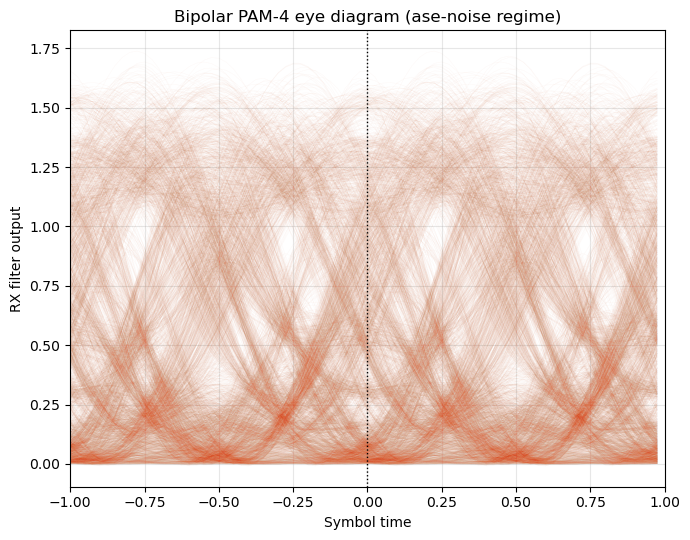

In [3]:
import torch.nn.functional as F

def draw_eye(ax, signal, samples_per_symbol, phase, title, fine_sps=40, skip=100, num_symbols=4000):
    fine = resample_poly(signal[:(skip + num_symbols + 8) * samples_per_symbol],
                         fine_sps, samples_per_symbol)
    offset = int(round(phase * fine_sps / samples_per_symbol))
    centers = (skip + np.arange(num_symbols)) * fine_sps + offset
    keep = (centers - fine_sps >= 0) & (centers + fine_sps < len(fine))
    centers = centers[keep]
    window = np.arange(-fine_sps, fine_sps)[:, None] + centers[None, :]
    ax.plot(np.arange(-fine_sps, fine_sps) / fine_sps, fine[window],
            color=(0.85, 0.33, 0.10, 0.03), linewidth=0.4)
    ax.axvline(0, color="k", linestyle=":", linewidth=1)
    ax.set_xlim(-1, 1)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Symbol time")
    ax.set_ylabel("RX filter output")
    ax.set_title(title)


sps = config.samples_per_symbol_sim
mf_pad = receiver.matched.shape[-1] // 2
with torch.no_grad():
    bits = random_bits(config.bits_per_symbol, 6000, device)
    symbols = bits_to_symbols(bits, config.bits_per_symbol).cpu().numpy()
    if config.noise_regime == "ase":
        # The A.47 receiver decides on the complex envelope after the matched filter,
        # i.e., on the optical field amplitude, NOT on the intensity
        field_real, field_imag = channel.complex_envelope(transmitter(bits), None)   # noiseless optical field
        mr = F.conv1d(field_real.view(1, 1, -1), receiver.matched, padding=mf_pad).squeeze()
        mi = F.conv1d(field_imag.view(1, 1, -1), receiver.matched, padding=mf_pad).squeeze()
        matched = torch.sqrt(mr ** 2 + mi ** 2).cpu().numpy()                       # envelope (equispaced amplitudes)
        matched = (mr ** 2 + mi ** 2).cpu().numpy()
    else:
        photocurrent = channel(transmitter(bits))                                  # noiseless square-law photocurrent
        matched = F.conv1d(photocurrent.view(1, 1, -1), receiver.matched, padding=mf_pad).squeeze().cpu().numpy()

# Sample at the matched-filter peak (the phase that best separates the levels) -- for the time-rect
# integrate-and-dump that peak is the symbol CENTRE, not the symbol boundary (offset 0).
phase, level_by_symbol = decision_phase_by_separation(matched, sps, symbols, skip=100)
levels = np.sort(level_by_symbol)
gaps = np.diff(levels)
print(f"levels at the sampling instant (low->high): {np.round(levels, 4)}")
print(f"sorted gaps: {np.round(gaps, 4)}   spread std/mean = {gaps.std() / gaps.mean():.3f}")

pam_name = "Bipolar" if config.modulation_format == "bpam-4" else "Unipolar"
fig_eye, ax_eye = plt.subplots(figsize=(7, 5.5))
draw_eye(ax_eye, matched, sps, phase, f"{pam_name} PAM-4 eye diagram ({config.noise_regime}-noise regime)")
fig_eye.tight_layout()
fig_eye.savefig(os.path.join("results", "pam4_eye.png"), dpi=150, bbox_inches="tight")
plt.show()


## BER vs $E_b/N_0$ curves

  Eb/N0     measured     theory
    6.0    1.059e-01    1.602e-01
    8.0    4.942e-02    1.068e-01
   10.0    1.582e-02    5.838e-02
   12.0    2.993e-03    2.341e-02
   14.0    2.984e-04    5.763e-03
   16.0    1.360e-05    6.563e-04
   18.0    4.500e-07    2.202e-05
   20.0    0.000e+00    1.063e-07


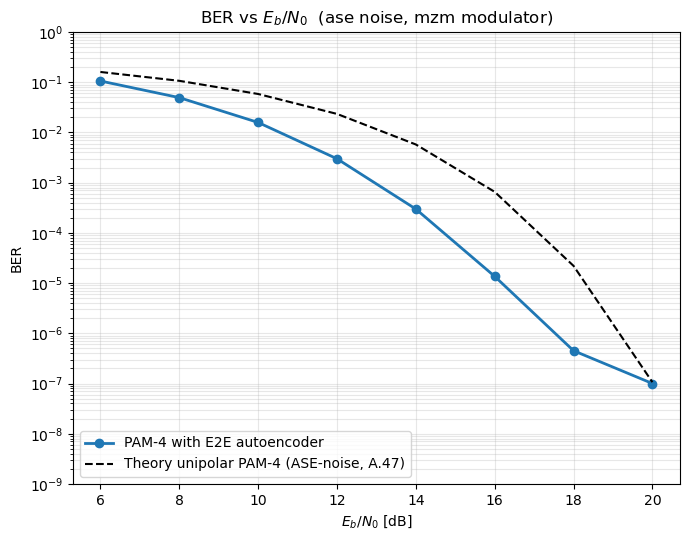

In [4]:
if config.noise_regime == "ase":
    theory = theoretical_ber_unipolar_ase(ebn0_db, config.modulation_order)
    theory_label = "Theory unipolar PAM-4 (ASE-noise, A.47)"
else:
    theory = theoretical_ber_unipolar(ebn0_db, config.modulation_order)
    theory_label = "Theory unipolar PAM-4 (thermal-noise, A.19)"
measured_floor = np.maximum(measured, 1.0 / NUM_EVAL)   # smallest resolvable BER

eq_label = {"end-to-end": "PAM-4 with E2E autoencoder", "ffe": "PAM-4 with FFE only",
            "threshold": "PAM-4 with decision threshold"}.get(config.equalizer, str(config.equalizer))

print("  Eb/N0     measured     theory")
for e, m, t in zip(ebn0_db, measured, theory):
    print(f"  {e:5.1f}    {m:.3e}    {t:.3e}")

fig_ber, ax_ber = plt.subplots(figsize=(7, 5.5))
ax_ber.semilogy(ebn0_db, measured_floor, "-o", linewidth=2, label=eq_label)
ax_ber.semilogy(ebn0_db, theory, "k--", linewidth=1.5, label=theory_label)
ax_ber.grid(True, which="both", alpha=0.3)
ax_ber.set_xlabel(r"$E_b/N_0$ [dB]")
ax_ber.set_ylabel("BER")
ax_ber.set_ylim(1e-9, 1)
ax_ber.set_title(f"BER vs $E_b/N_0$  ({config.noise_regime} noise, {config.modulator} modulator)")
ax_ber.legend(loc="lower left")
fig_ber.tight_layout()
fig_ber.savefig(os.path.join("results", "pam4_ber.png"), dpi=150, bbox_inches="tight")
plt.show()